<script type="text/javascript" src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.7/MathJax.js?config=TeX-MML-AM_CHTML"></script>
# Assignment: Expressivity & Message Passing

# Introduction

This assignment covers the theoretical foundations and practical implementation of Graph Neural Networks (GNNs).

1. **Expressivity and the WL Test**: Implement the 1-WL test and identify cases where standard message passing fails.
2. **DeepSets**: Implement the DeepSets framework and apply it to point cloud classification.
3. **GNN from Scratch (Karate Club)**: Build a GNN layer and study how message passing enables community detection with minimal supervision.

In [2]:
# self added begin
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# self added end

import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import Counter

import numpy as np
import networkx as nx

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)

c:\Users\Lukas\anaconda3\envs\comvision\Lib\site-packages\networkx\utils\backends.py:102: RuntimeWarning: networkx backend name is not a valid identifier: 'nx-loopback'. Ignoring.
  backends = _get_backends("networkx.backends")


Using device: cpu


# Part 1: The Weisfeiler-Lehman (WL) Test

The **1-WL test** (color refinement) iteratively updates node labels by hashing the multiset of neighbor labels:

$$
c_i^{(k)} = \text{HASH} \left( c_i^{(k-1)}, \{\{ c_j^{(k-1)} : j \in \mathcal{N}(i) \}\} \right)
$$

Standard GNNs follow a similar message-passing structure:

$$
\mathbf{h}_i^{(k)} = \phi \left( \mathbf{h}_i^{(k-1)}, \bigoplus_{j \in \mathcal{N}(i)} \psi \left( \mathbf{h}_i^{(k-1)}, \mathbf{h}_j^{(k-1)} \right) \right)
$$

Crucially, GNNs are **at most as expressive as 1-WL** in distinguishing graph structures.

<div class="alert alert-info">
    <h3>Utility: Graph Plotting with WL Colors</h3>
    Nothing to do here, just run the cell. This function visualizes a graph and colors nodes based on the partitions found by the WL test.
</div>

In [3]:
def plot_graph(
    G: nx.Graph,
    colors: list = None,
    pos: dict = None,
    title: str = "Graph Visualization",
    sizes: list = None,
    edgecolors: list = None,
):
    """Plots a graph with flexible node coloring and sizing."""
    plt.figure(figsize=(7, 5))
    if pos is None:
        pos = nx.kamada_kawai_layout(G)

    if colors is not None:
        if isinstance(colors[0], (int, np.integer, str)):
            unique_labels = sorted(list(set(colors)))
            label_to_idx = {l: i for i, l in enumerate(unique_labels)}
            node_colors = [label_to_idx[c] for c in colors]
            cmap = plt.cm.tab10
            vmin, vmax = 0, 9
            node_labels = {
                node: str(label_to_idx[colors[i]]) for i, node in enumerate(G.nodes())
            }
        else:
            # Continuous values (like magnitudes)
            node_colors = colors
            cmap = plt.cm.plasma
            vmin, vmax = None, None
            node_labels = {node: str(node) for node in G.nodes()}
    else:
        node_colors = "lightblue"
        cmap = None
        vmin, vmax = None, None
        node_labels = {node: str(node) for node in G.nodes()}

    node_size = sizes if sizes is not None else 800
    edgecolors = edgecolors if edgecolors is not None else "gray"

    nx.draw(
        G,
        pos,
        labels=node_labels,
        with_labels=True,
        node_color=node_colors,
        cmap=cmap,
        node_size=node_size,
        edge_color="gray",
        width=1.5,
        vmin=vmin,
        vmax=vmax,
        font_weight="bold",
        font_color="black",
        font_size=10,
        edgecolors=edgecolors,
    )
    plt.title(title)
    plt.show()

<div class="alert alert-warning">
    <h3>Task 1.1: 1-WL Implementation</h3>
    Implement the <code>wl_1_test</code> function. The function should perform color refinement until the partition of nodes stabilizes. Return the final colors as a list of integers.
</div>

In [4]:
def wl_1_test(G: nx.Graph, max_iter: int = 100) -> list[int]:
    """Performs the 1-WL color refinement algorithm."""
    nodes = list(G.nodes())
    colors = {node: 1 for node in nodes}

    # YOUR CODE HERE
    
    for _ in range(max_iter):
        # empty dict for singatures (own current color, sorted colors of neighbours)
        signatures = {}

        for node in nodes:
            #get colors from neighbours
            neighbor_colors = [colors[neighbor] for neighbor in G.neighbors(node)]
            # sort them bc it doesnt matter wich color comes first
            neighbor_colors.sort()
            # build signature of the nodes
            signature = (colors[node], tuple(neighbor_colors))
            # save signature of the current node
            signatures[node] = signature
        # get all different signatures
        unique_signatures = sorted(set(signatures.values()))
        # every different signature gets a new integer color
        signature_to_color = {
            signature: idx + 1 for idx, signature in enumerate(unique_signatures)
        }

        # set actual color
        new_colors = {
            node: signature_to_color[signatures[node]] for node in nodes
        }

        # does the color change? if not end here
        if new_colors == colors:
            break
        
        # replace current colors with new colors
        colors = new_colors
    #return final colors as a list
    return [colors[node] for node in nodes]

<div class="alert alert-info">
    <h3>Example: Successful graph partitioning</h3>
    Run this cell to see how 1-WL successfully distinguishes structural roles in an asymmetric graph (a ring with a tail). Observe how nodes receive different <b>Color IDs</b> based on their local topology.
</div>

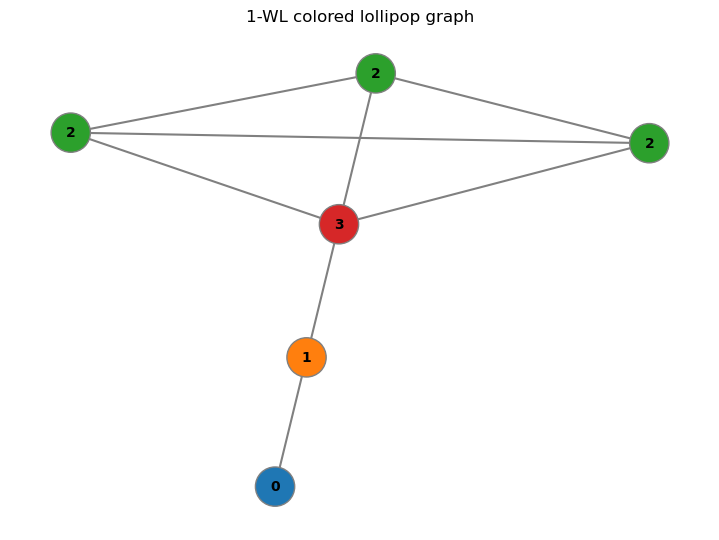

In [5]:
G_mol = nx.lollipop_graph(m=4, n=2)
colors_mol = wl_1_test(G_mol)
plot_graph(G_mol, colors_mol, title="1-WL colored lollipop graph")

<div class="alert alert-warning">
    <h3>Task 1.2: 1-WL Failure Case (Regular Graphs)</h3>
    1-WL fails to distinguish certain non-isomorphic connected graphs, such as k-regular graphs. Construct two <b>non-isomorphic</b> graphs (<code>G1</code>, <code>G2</code>) where 1-WL fails.
</div>

Distinguished by 1-WL? False


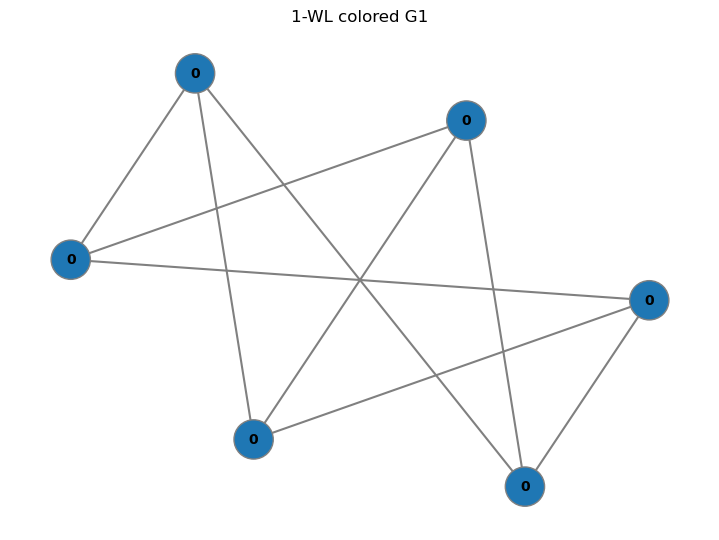

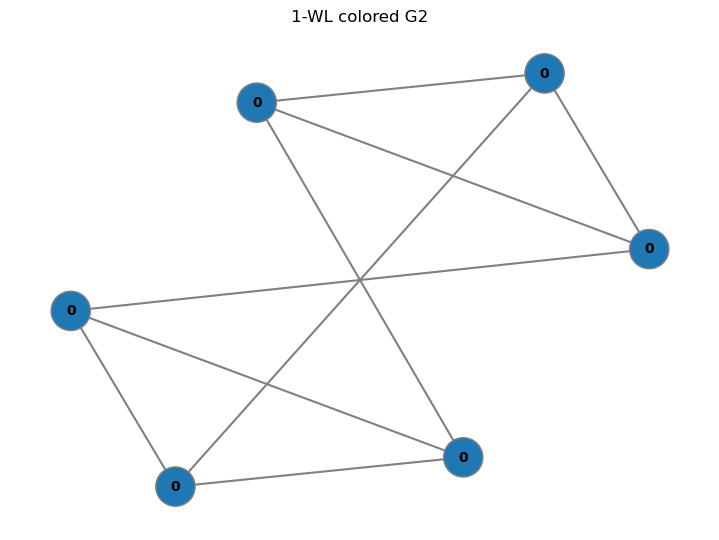

In [6]:
G1 = nx.Graph()
G2 = nx.Graph()

# YOUR CODE HERE

# G1: Complete bipartite graph K_{3,3} (contains no triangles)
G1.add_nodes_from(range(6))
G1.add_edges_from([
    (0, 3), (0, 4), (0, 5),
    (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
])

# G2: Triangular prism graph (contains two traingles)
G2.add_nodes_from(range(6))
G2.add_edges_from([
    (0, 1), (1, 2), (2, 0),
    (3, 4), (4, 5), (5, 3),
    (0, 3), (1, 4), (2, 5),
])

colors1 = wl_1_test(G1)
colors2 = wl_1_test(G2)

print(f"Distinguished by 1-WL? {Counter(colors1) != Counter(colors2)}")
plot_graph(G1, colors1, title="1-WL colored G1")
plot_graph(G2, colors2, title="1-WL colored G2")

<div class="alert alert-warning">
    <h3>Question 1.3</h3>
    Consider the two non-isomorphic graphs you constructed in Task 1.2.
    <ol>
        <li>Using the 1-WL update rule \(c_i^{(k)} = \text{HASH}\left(c_i^{(k-1)},\{\{c_j^{(k-1)} : j \in \mathcal{N}(i)\}\}\right)\), explain step by step why all nodes receive the same color after every iteration.</li>
        <li>What structural property of these graphs causes 1-WL to fail? Could a standard message passing GNN distinguish them?</li>
    </ol>
    Write your answer in the cell below.
<br><i>Note: answering one part thoroughly is sufficient for full credit.</i>
</div>

*Your answer here.*

1. Both graphs are 3-regular, meaning that every node has exactly three neighbors. 
At the beginning of the 1-WL algorithm, all nodes get the same initial color, for example color 1. In the first iteration, every node sees the same information: its own color is 1, and all of its three neighbors also have color 1. Therefore, every node has the same WL signature: HASH(1, {{1, 1, 1}}) Since the input to the HASH function is the same for every node, all nodes receive the same new color. The same argument repeats in every later iteration. If all nodes have the same color in iteration k-1, then every node again sees three neighbors with that same color. Therefore, all nodes again receive the same color in iteration k. Thus, 1-WL cannot distinguish the two graphs because both always have the same color distribution.

2. The structural reason is that both graphs are regular with the same number of nodes and the same degree. From the local message-passing view of 1-WL, every node looks identical. A standard message-passing GNN would also not be able to distinguish them if all nodes start with identical features, because it aggregates neighbor information in the same way as 1-WL. Since every node receives the same type of messages in every layer, the node embeddings remain the same.

## Part 2: DeepSets

The **DeepSets** framework (Zaheer et al., 2017) shows that any permutation-invariant function $f$ on a set can be decomposed as:

$$
f(\{x_1, \ldots, x_n\}) = \rho \left( \sum_{i=1}^{n} \phi(x_i) \right)
$$

where $\phi$ is a per-element encoder and $\rho$ maps the aggregated representation to the output. This is directly related to the **aggregation step** in GNNs — the aggregation $\bigoplus$ over the neighbor multiset is exactly a DeepSet applied to the local neighborhood.

<div class="alert alert-info">
    <h3>Utility: Synthetic Point Cloud Generation</h3>
    Nothing to do here, just run the cell. We generate synthetic 2D point clouds of circles, squares, and triangles for classification.
</div>

In [7]:
def generate_point_clouds(n_samples_per_class=200, n_points=40, noise=0.05):
    """Generates 2D point clouds for three shape classes."""
    clouds = []
    labels = []

    for _ in range(n_samples_per_class):
        # Class 0: Circle
        theta = np.random.uniform(0, 2 * np.pi, n_points)
        x = np.cos(theta) + np.random.randn(n_points) * noise
        y = np.sin(theta) + np.random.randn(n_points) * noise
        clouds.append(np.stack([x, y], axis=1))
        labels.append(0)

        # Class 1: Square
        side = np.random.randint(0, 4, n_points)
        t = np.random.uniform(-1, 1, n_points)
        x = np.where(side == 0, t, np.where(side == 1, 1, np.where(side == 2, t, -1)))
        y = np.where(side == 0, 1, np.where(side == 1, t, np.where(side == 2, -1, t)))
        x = x + np.random.randn(n_points) * noise
        y = y + np.random.randn(n_points) * noise
        clouds.append(np.stack([x, y], axis=1))
        labels.append(1)

        # Class 2: Triangle
        side = np.random.randint(0, 3, n_points)
        t = np.random.uniform(0, 1, n_points)
        vertices = np.array([[0, 1], [-np.sqrt(3)/2, -0.5], [np.sqrt(3)/2, -0.5]])
        p0, p1 = vertices[side], vertices[(side + 1) % 3]
        points = p0 + t[:, None] * (p1 - p0)
        points += np.random.randn(n_points, 2) * noise
        clouds.append(points)
        labels.append(2)

    clouds = torch.FloatTensor(np.array(clouds))
    labels = torch.LongTensor(labels)

    # Shuffle
    perm = torch.randperm(len(labels))
    return clouds[perm], labels[perm]


clouds, cloud_labels = generate_point_clouds()
n_train = int(0.8 * len(clouds))
train_clouds, test_clouds = clouds[:n_train].to(device), clouds[n_train:].to(device)
train_labels, test_labels = cloud_labels[:n_train].to(device), cloud_labels[n_train:].to(device)

print(f"Point clouds shape: {clouds.shape}")
print(f"Labels distribution: {Counter(cloud_labels.tolist())}")

Point clouds shape: torch.Size([600, 40, 2])
Labels distribution: Counter({0: 200, 1: 200, 2: 200})


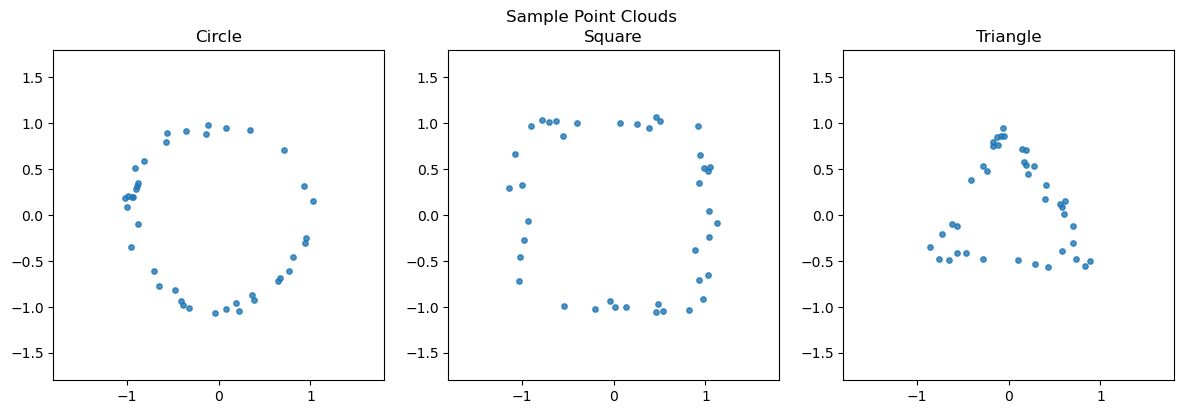

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
class_names = ["Circle", "Square", "Triangle"]
for cls in range(3):
    idx = (cloud_labels == cls).nonzero(as_tuple=True)[0][0]
    axes[cls].scatter(clouds[idx, :, 0], clouds[idx, :, 1], s=15, alpha=0.8)
    axes[cls].set_title(class_names[cls])
    axes[cls].set_aspect("equal")
    axes[cls].set_xlim(-1.8, 1.8)
    axes[cls].set_ylim(-1.8, 1.8)
plt.suptitle("Sample Point Clouds")
plt.tight_layout()
plt.show()

<div class="alert alert-warning">
    <h3>Task 2.1: DeepSet Implementation</h3>
    Implement the <code>DeepSet</code> model following the decomposition \(f(\{x_1, \ldots, x_n\}) = \rho\left(\sum_i \phi(x_i)\right)\):
    <ol>
        <li><code>phi</code>: a per-element encoder.</li>
        <li><b>Sum aggregation</b> over the set dimension to obtain a permutation-invariant representation.</li>
        <li><code>rho</code>: a classifier head mapping the aggregated representation to class logits.</li>
    </ol>
</div>

In [9]:
class DeepSet(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # YOUR CODE HERE
        
        # compute higher dimensional representation of in_dim to hidden dim (sort of small MLP) (per-element encoder)
        self.phi = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # compute final logits of out_dim
        self.rho = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        """
        Args:
            x: (batch_size, n_points, in_dim)
        Returns:
            (batch_size, out_dim)
        """
        # YOUR CODE HERE
        
        # apply phi on coordinates -> higher dimensional representation
        point_embeddings = self.phi(x)
        # aggregate sum (order doesnt matter) dim=1 for points
        set_embedding = point_embeddings.sum(dim=1)
        # rho now processes entire point cloud representation
        logits = self.rho(set_embedding)

        return logits
    

<div class="alert alert-warning">
    <h3>Task 2.2: Training & Evaluation</h3>
    Train the DeepSet on the shape classification task using <b>cross entropy loss</b>. Report test accuracy.
</div>

In [10]:
deepset = DeepSet(in_dim=2, hidden_dim=64, out_dim=3).to(device)
optimizer = torch.optim.Adam(deepset.parameters(), lr=1e-3)

# YOUR CODE HERE

# define loss
criterion = nn.CrossEntropyLoss()
# define number of epochs
n_epochs = 200

# for every epoch
for epoch in range(n_epochs):
    # put the model in train mode
    deepset.train()
    # set the grads to zero so thhey dont get accumulated
    optimizer.zero_grad()
    # computes the logits (3 values for every class)
    logits = deepset(train_clouds)
    # compute the loss
    loss = criterion(logits, train_labels)
    # compute the grads
    loss.backward()
    # advance one step
    optimizer.step()

    # print statements every 20 epochs
    if (epoch + 1) % 20 == 0:
        preds = logits.argmax(dim=1)
        train_acc = (preds == train_labels).float().mean()
        print(
            f"Epoch {epoch + 1:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Train Accuracy: {train_acc:.4f}"
        )

# Test accuracy
deepset.eval()
with torch.no_grad():
    test_logits = deepset(test_clouds)
    test_preds = test_logits.argmax(dim=1)
    test_acc = (test_preds == test_labels).float().mean()
    print(f"\nTest Accuracy: {test_acc:.4f}")

Epoch 020 | Loss: 0.7877 | Train Accuracy: 0.7250
Epoch 040 | Loss: 0.5060 | Train Accuracy: 0.9208
Epoch 060 | Loss: 0.2875 | Train Accuracy: 0.9937
Epoch 080 | Loss: 0.1235 | Train Accuracy: 1.0000
Epoch 100 | Loss: 0.0451 | Train Accuracy: 1.0000
Epoch 120 | Loss: 0.0164 | Train Accuracy: 1.0000
Epoch 140 | Loss: 0.0071 | Train Accuracy: 1.0000
Epoch 160 | Loss: 0.0039 | Train Accuracy: 1.0000
Epoch 180 | Loss: 0.0025 | Train Accuracy: 1.0000
Epoch 200 | Loss: 0.0017 | Train Accuracy: 1.0000

Test Accuracy: 1.0000


<div class="alert alert-info">
    <h3>Verifying Permutation Invariance</h3>
    A function \(f\) on a set is <b>permutation invariant</b> if its output does not depend on the ordering of the input elements. Formally, for any permutation \(\pi\):
    \[f(\{x_1, \ldots, x_n\}) = f(\{x_{\pi(1)}, \ldots, x_{\pi(n)}\})\]
    This is a critical property for set-based learning: a point cloud representing a circle is the same circle regardless of how we index its points. In DeepSets, permutation invariance is guaranteed <b>by construction</b> — the sum aggregation \(\sum_i \phi(x_i)\) is invariant to reordering because addition is commutative. We verify this empirically below by shuffling the point order within each cloud and checking that the model's output remains unchanged.
</div>

In [11]:
deepset.eval()
with torch.no_grad():
    sample = test_clouds[:10]
    out_original = deepset(sample)

    # shuffle point order within each cloud
    perm = torch.stack([torch.randperm(sample.shape[1], device=device) for _ in range(sample.shape[0])])
    shuffled = torch.gather(sample, 1, perm.unsqueeze(-1).expand_as(sample))
    out_shuffled = deepset(shuffled)

    max_diff = (out_original - out_shuffled).abs().max().item()
    print(f"Max output difference after shuffling: {max_diff:.2e}")
    print(f"Permutation invariant: {torch.allclose(out_original, out_shuffled, atol=1e-5)}")

Max output difference after shuffling: 1.91e-06
Permutation invariant: True


<div class="alert alert-warning">
    <h3>Question 2.3</h3>
    <ol>
        <li>Prove that the DeepSet forward pass \(f(\{x_1, \ldots, x_n\}) = \rho\!\left(\sum_i \phi(x_i)\right)\) is permutation invariant. <i>Hint: consider any permutation \(\pi\) and show \(f(\{x_{\pi(1)}, \ldots, x_{\pi(n)}\}) = f(\{x_1, \ldots, x_n\})\).</i></li>
        <li>Would replacing sum with <b>mean</b> or <b>max</b> preserve permutation invariance? Would it preserve the ability to distinguish multisets of different sizes (e.g. \(\{1, 1\}\) vs \(\{1, 1, 1\}\))?</li>
    </ol>
    Write your answer in the cell below.
<br><i>Note: answering one part thoroughly is sufficient for full credit.</i>
</div>

*Your answer here.*

The DeepSet model is **permutation invariant** because the aggregation operation is a sum.

Let $\pi$ be any permutation of the input elements. Then:

$$
f(\{x_{\pi(1)}, \ldots, x_{\pi(n)}\})
=
\rho\left(\sum_i \phi(x_{\pi(i)})\right)
$$

Since summation is commutative and associative, changing the order of the terms does not change the result:

$$
\sum_i \phi(x_{\pi(i)})
=
\sum_i \phi(x_i)
$$

Therefore:

$$
f(\{x_{\pi(1)}, \ldots, x_{\pi(n)}\})
=
\rho\left(\sum_i \phi(x_i)\right)
=
f(\{x_1, \ldots, x_n\})
$$

So the output is independent of the order of the elements.

Replacing **sum** with **mean** or **max** would also preserve permutation invariance, because these operations do not depend on the order of the elements.

However, **mean** and **max** may lose information about multiplicities or set size. For example:

$$
\text{mean}(\{1,1\}) = \text{mean}(\{1,1,1\}) = 1
$$

and

$$
\max(\{1,1\}) = \max(\{1,1,1\}) = 1
$$

But **sum** can distinguish them:

$$
\sum \{1,1\} = 2
$$

while

$$
\sum \{1,1,1\} = 3
$$

Therefore, **sum**, **mean**, and **max** are all permutation invariant, but **sum** preserves more information about the size and multiplicity of the multiset.

<div class="alert alert-info">
    <h3>When DeepSets Fail</h3>
    DeepSets treat each element <b>independently</b> before aggregation — the encoder \(\phi\) never sees pairs of elements. This makes them blind to <b>relational structure</b>.
    <br><br>
    Below, both classes sample points from \(\mathcal{N}(0, I)\) — the per-point marginals are identical. The only difference: in class 1, points come in <b>close pairs</b> (each center has a nearby partner at distance ~0.1), while class 0 has independent points. Since \(\sum \phi(x_i)\) depends only on individual point positions, the DeepSet cannot detect the pairing.
</div>

DeepSet accuracy on pairing task: 0.6833


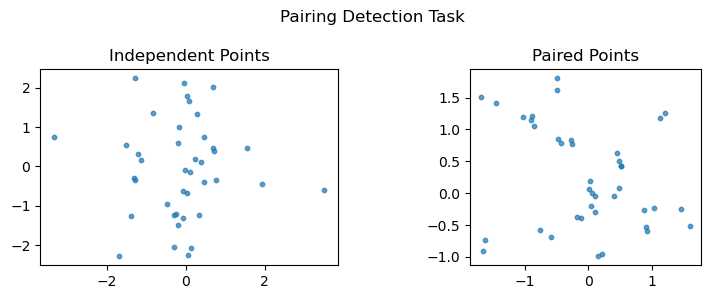

In [12]:
def generate_pairing_data(n_samples=300, n_points=40, pair_noise=0.1):
    """Class 0: iid points from N(0,I). Class 1: paired points (close duplicates).
    Per-point marginals are nearly identical — only pairwise structure differs."""
    clouds, labels = [], []
    for _ in range(n_samples):
        # Class 0: independent points
        clouds.append(np.random.randn(n_points, 2))
        labels.append(0)

        # Class 1: N/2 centers, each with a nearby partner
        centers = np.random.randn(n_points // 2, 2)
        partners = centers + np.random.randn(n_points // 2, 2) * pair_noise
        cloud = np.concatenate([centers, partners], axis=0)
        np.random.shuffle(cloud)  # hide the pairing order
        clouds.append(cloud)
        labels.append(1)

    clouds = torch.FloatTensor(np.array(clouds))
    labels = torch.LongTensor(labels)
    perm = torch.randperm(len(labels))
    return clouds[perm], labels[perm]


pair_clouds, pair_labels = generate_pairing_data()
n_cl = int(0.8 * len(pair_clouds))
cl_train_x, cl_test_x = pair_clouds[:n_cl].to(device), pair_clouds[n_cl:].to(device)
cl_train_y, cl_test_y = pair_labels[:n_cl].to(device), pair_labels[n_cl:].to(device)

# Train DeepSet
ds_pair = DeepSet(in_dim=2, hidden_dim=64, out_dim=2).to(device)
opt = torch.optim.Adam(ds_pair.parameters(), lr=1e-3)
for epoch in range(200):
    ds_pair.train()
    loss = F.cross_entropy(ds_pair(cl_train_x), cl_train_y)
    opt.zero_grad(); loss.backward(); opt.step()

ds_pair.eval()
with torch.no_grad():
    acc = (ds_pair(cl_test_x).argmax(1) == cl_test_y).float().mean()
print(f"DeepSet accuracy on pairing task: {acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for cls, title in [(0, "Independent Points"), (1, "Paired Points")]:
    idx = (pair_labels == cls).nonzero(as_tuple=True)[0][0]
    axes[cls].scatter(pair_clouds[idx, :, 0], pair_clouds[idx, :, 1], s=10, alpha=0.7)
    axes[cls].set_title(title)
    axes[cls].set_aspect("equal")
plt.suptitle("Pairing Detection Task")
plt.tight_layout()
plt.show()

# Part 3: GNN on Karate Club

The **Karate Club** dataset represents social ties between 34 members of a karate club that split into two factions. We use an **identity matrix** as initial features (no node attributes), forcing the GNN to learn purely from structure.

**Adjacency representations:** an adjacency matrix $A \in \mathbb{R}^{N \times N}$ is intuitive but $O(N^2)$ in memory. Edge lists $E \in \mathbb{R}^{2 \times |E|}$ scale better via scatter/gather operations.

<div class="alert alert-warning">
    <h3>Task 3.1: Data Preparation</h3>
    <ol>
        <li>Load the graph using <code>nx.karate_club_graph()</code>.</li>
        <li>Convert it to a <b>normalized</b> adjacency matrix \(\hat{A} = D^{-1/2}(A+I)D^{-1/2}\) for stable training.</li>
        <li>Create labels: 0 for "Mr. Hi" club, 1 for "Officer" club.</li>
        <li>Initialize features as an identity matrix.</li>
    </ol>
    <i>Tip: the club attribute is stored in <code>G.nodes[i]["club"]</code>.</i>
</div>

In [ ]:
# YOUR CODE HERE

# load karate club graph
G_karate = nx.karate_club_graph()

# save list of all nodes
nodes = list(G_karate.nodes())
# extract number of nodes
num_nodes = G_karate.number_of_nodes()

# transform graph to adjacency matrix
A = nx.to_numpy_array(G_karate, nodelist=nodes)

# add self loops to adjacency matrix
A_tilde = A + np.eye(num_nodes)

# calculate degrees of every node
degrees = A_tilde.sum(axis=1)

# create diagonal matrix of degrees
D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))

# calculate normalised adjacency matrix
A_hat = D_inv_sqrt @ A_tilde @ D_inv_sqrt

# transform normlasied adjacency matrix to torch tensor
adj_karate = torch.FloatTensor(A_hat).to(device)

# create starting features as identity matrix (one-hot vector)
features_karate = torch.eye(num_nodes).to(device)

# create labels
labels_karate = torch.LongTensor([
    0 if G_karate.nodes[node]["club"] == "Mr. Hi" else 1
    for node in nodes
]).to(device)

print(f"Adjacency Matrix (Normalized) Shape: {adj_karate.shape}")

Adjacency Matrix (Normalized) Shape: torch.Size([34, 34])


<div class="alert alert-info">
    <h3>Zachary's Karate Club</h3>
</div>

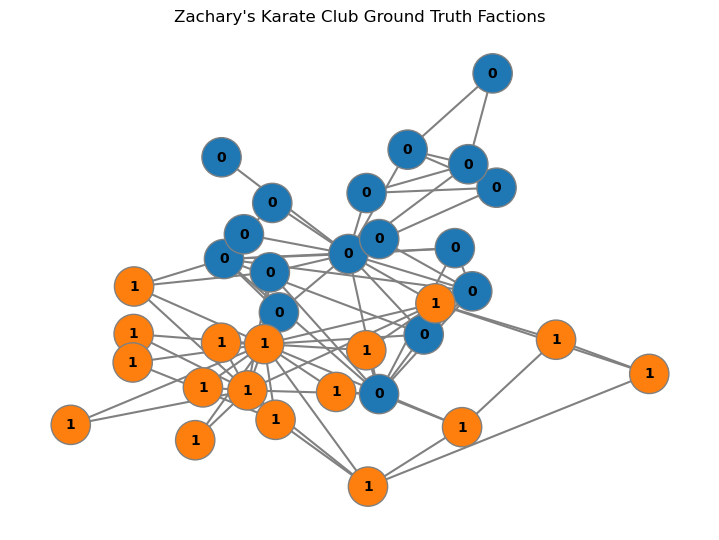

In [15]:
plot_graph(
    G_karate,
    colors=labels_karate.tolist(),
    title="Zachary's Karate Club Ground Truth Factions",
)

<div class="alert alert-warning">
    <h3>Task 3.2: GNNLayer Implementation</h3>
    Implement the <code>message</code> and <code>update</code> methods. Use the message passing layer of your choice.
</div>

In [ ]:
class GNNLayer(nn.Module):
    def __init__(self, in_features, out_features, activation=F.relu):
        super().__init__()
        self.activation = activation
        # YOUR CODE HERE
        
        self.linear = nn.Linear(in_features, out_features)

    def message(self, x, adj):
        # YOUR CODE HERE
        
        messages = adj @ x
        return messages
    
    def update(self, x, messages):
        # YOUR CODE HERE
        
        out = self.linear(messages)

        if self.activation is not None:
            out = self.activation(out)
            
        return out
    
    def forward(self, x, adj):
        return self.update(x, self.message(x, adj))

<div class="alert alert-warning">
    <h3>Task 3.3: Structural Influence Study</h3>
    In this task, you will train a single GNN model and evaluate its reliance on connectivity.
    <ol>
        <li>Train the model on <b>cross entropy loss</b>, and with labels for <b>only 4 nodes (0, 1, 32, 33)</b>.</li>
        <li>Compare the accuracy of a GNN on the full graph versus an MLP on the nodes, without accounting for edges.</li>
    </ol>
</div>

In [17]:
train_mask = torch.zeros(34, dtype=torch.bool).to(device)
train_mask[[0, 1, 32, 33]] = True


class KarateModel(nn.Module):
    def __init__(self, n_nodes):
        super().__init__()
        self.layer1 = GNNLayer(n_nodes, 16)
        self.layer2 = GNNLayer(16, 2, activation=None)

    def forward(self, x, adj):
        h = self.layer1(x, adj)
        return self.layer2(h, adj)


class MLP(nn.Module):
    def __init__(self, n_nodes):
        super().__init__()
        self.layer1 = nn.Linear(n_nodes, 16)
        self.layer2 = nn.Linear(16, 2)

    def forward(self, x):
        h = F.relu(self.layer1(x))
        return self.layer2(h)


# YOUR CODE HERE

gnn = KarateModel(n_nodes=34).to(device)
mlp = MLP(n_nodes=34).to(device)

criterion = nn.CrossEntropyLoss()

optimizer_gnn = torch.optim.Adam(gnn.parameters(), lr=1e-2, weight_decay=5e-4)
optimizer_mlp = torch.optim.Adam(mlp.parameters(), lr=1e-2, weight_decay=5e-4)

n_epochs = 300

for epoch in range(n_epochs):
    gnn.train()
    optimizer_gnn.zero_grad()

    out_gnn = gnn(features_karate, adj_karate)
    loss_gnn = criterion(out_gnn[train_mask], labels_karate[train_mask])

    loss_gnn.backward()
    optimizer_gnn.step()

    mlp.train()
    optimizer_mlp.zero_grad()

    out_mlp = mlp(features_karate)
    loss_mlp = criterion(out_mlp[train_mask], labels_karate[train_mask])

    loss_mlp.backward()
    optimizer_mlp.step()

    if (epoch + 1) % 50 == 0:
        gnn.eval()
        mlp.eval()

        with torch.no_grad():
            out_gnn_eval = gnn(features_karate, adj_karate)
            pred_gnn = out_gnn_eval.argmax(dim=1)
            acc_gnn = (pred_gnn == labels_karate).float().mean()

            out_mlp_eval = mlp(features_karate)
            pred_mlp = out_mlp_eval.argmax(dim=1)
            acc_mlp = (pred_mlp == labels_karate).float().mean()

        print(
            f"Epoch {epoch + 1:03d} | "
            f"GNN Loss: {loss_gnn.item():.4f} | "
            f"GNN Acc: {acc_gnn:.4f} | "
            f"MLP Loss: {loss_mlp.item():.4f} | "
            f"MLP Acc: {acc_mlp:.4f}"
        )

gnn.eval()
mlp.eval()

with torch.no_grad():
    out_full = gnn(features_karate, adj_karate)
    pred_gnn = out_full.argmax(dim=1)
    acc_gnn = (pred_gnn == labels_karate).float().mean()

    out_mlp = mlp(features_karate)
    pred_mlp = out_mlp.argmax(dim=1)
    acc_mlp = (pred_mlp == labels_karate).float().mean()

print(f"\nFinal GNN Accuracy: {acc_gnn:.4f}")
print(f"Final MLP Accuracy: {acc_mlp:.4f}")

Epoch 050 | GNN Loss: 0.0091 | GNN Acc: 0.9706 | MLP Loss: 0.0112 | MLP Acc: 0.5588
Epoch 100 | GNN Loss: 0.0034 | GNN Acc: 0.9706 | MLP Loss: 0.0016 | MLP Acc: 0.5588
Epoch 150 | GNN Loss: 0.0019 | GNN Acc: 0.9706 | MLP Loss: 0.0011 | MLP Acc: 0.5588
Epoch 200 | GNN Loss: 0.0018 | GNN Acc: 1.0000 | MLP Loss: 0.0008 | MLP Acc: 0.5588
Epoch 250 | GNN Loss: 0.0017 | GNN Acc: 1.0000 | MLP Loss: 0.0008 | MLP Acc: 0.5588
Epoch 300 | GNN Loss: 0.0017 | GNN Acc: 1.0000 | MLP Loss: 0.0007 | MLP Acc: 0.5588

Final GNN Accuracy: 1.0000
Final MLP Accuracy: 0.5588


<div class="alert alert-info">
    <h3>Social Influence & Embedding Magnitude</h3>
    We visualize the Karate social network where:
    <ul>
        <li><b>Colors</b> represent the magnitude (L2 norm) of the learned node embeddings.</li>
        <li><b>Border (red)</b> highlights the 4 nodes used for training.</li>
    </ul>
    Observe how the learned magnitude correlates with the node"s position relative to the faction leaders!
</div>

Text(0.5, 1.0, 'Karate Club: Influence Map (Size=Confidence, Color=Magnitude)')

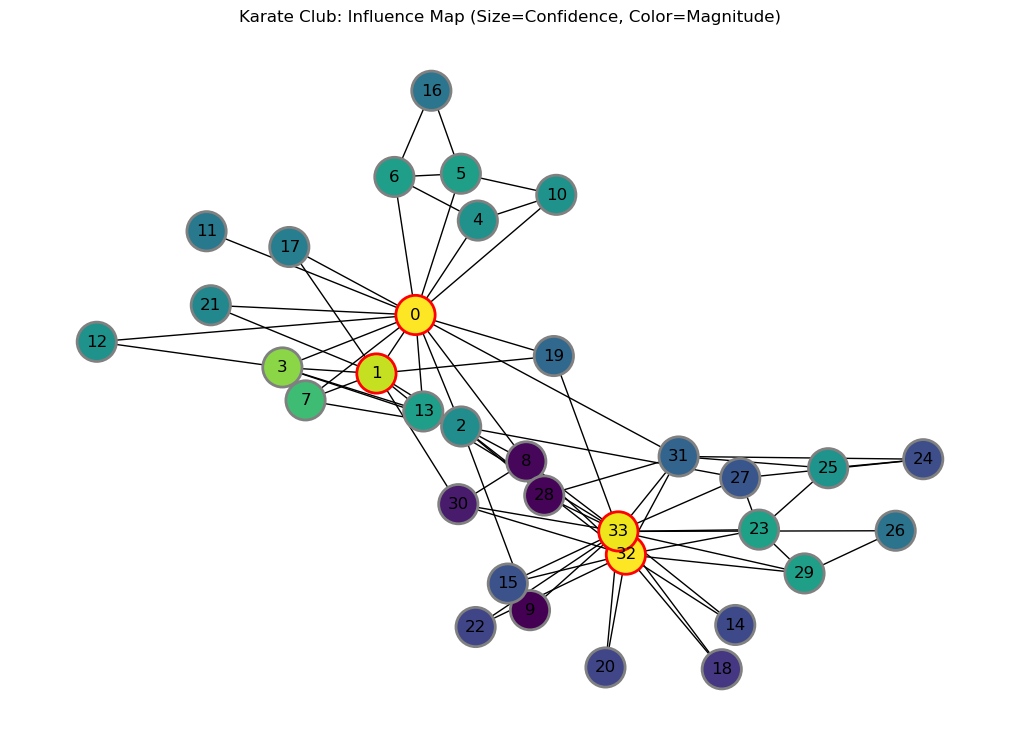

In [18]:
probs = F.softmax(out_full, dim=1)
magnitudes = torch.norm(out_full, p=2, dim=1).cpu().numpy()
edge_colors = ["red" if train_mask[i] else "gray" for i in range(34)]

plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_karate, seed=42)

nx.draw(
    G_karate,
    pos,
    with_labels=True,
    node_color=magnitudes,
    cmap="viridis",
    node_size=800,
    edgecolors=edge_colors,
    linewidths=2,
)
plt.title("Karate Club: Influence Map (Size=Confidence, Color=Magnitude)")

<div class="alert alert-warning">
    <h3>Question 3.4</h3>
    In Task 3.3 you trained a GNN on only 4 labeled nodes and achieved high accuracy on all 34 nodes.
    <ol>
        <li>Explain, in terms of the message passing equation \(\mathbf{h}_i^{(k)} = \phi\!\left(\mathbf{h}_i^{(k-1)}, \bigoplus_{j \in \mathcal{N}(i)} \psi(\mathbf{h}_j^{(k-1)})\right)\), how label information from the 4 training nodes reaches unlabeled nodes.</li>
        <li>The MLP baseline achieves ~50% (random chance). The input features are an identity matrix \(\mathbf{I}_{34}\). Why can't the MLP generalize from 4 training rows of \(\mathbf{I}\) to the other 30?</li>
    </ol>
    Write your answer in the cell below.
<br><i>Note: answering one part thoroughly is sufficient for full credit.</i>
</div>

*Your answer here.*

In a GNN, each node updates its representation by aggregating messages from its neighbors:

$$
\mathbf{h}_i^{(k)}
=
\phi\left(
\mathbf{h}_i^{(k-1)},
\bigoplus_{j \in \mathcal{N}(i)}
\psi(\mathbf{h}_j^{(k-1)})
\right)
$$

This means that information from the 4 labeled training nodes can flow through the edges of the graph.

After one GNN layer, a node contains information from its direct neighbors.  
After two GNN layers, it also contains information from nodes that are two hops away.

Therefore, the labels of nodes $0$, $1$, $32$, and $33$ can influence nearby unlabeled nodes through message passing.

This works well in the Karate Club graph because nodes in the same community are densely connected.  
So label information mostly spreads inside the correct community.

The MLP cannot do this because it does not use the adjacency matrix.  
It only sees the identity matrix:

$$
\mathbf{I}_{34}
$$

In this matrix, each node is represented by a unique one-hot vector.

Training on only 4 rows teaches the MLP only about those 4 specific node IDs.  
The other 30 one-hot vectors are different and have no structural relation to the training nodes.

Therefore, the MLP cannot generalize well to the unlabeled nodes and performs close to random chance.

<div class="alert alert-info">
    <h3>Bonus: GNNs vs DeepSets</h3>
    Recall that the DeepSet failed on the cluster detection task because it processes each point independently. A GNN, on the other hand, exchanges messages between connected nodes — giving it access to relational information.
    <br><br>
    Below we build a <b>k-nearest-neighbor graph</b> from each point cloud and run the GNNLayer you implemented in Part 3. The GNN succeeds where the DeepSet failed.
</div>

In [19]:
def knn_adjacency(points, k=5):
    """Build a symmetric k-NN adjacency matrix (vectorized, no Python loop)."""
    dists = torch.cdist(points, points)
    _, idx = dists.topk(k + 1, largest=False)  # +1 for self
    N = points.shape[0]
    adj = torch.zeros(N, N, device=points.device)
    rows = torch.arange(N, device=points.device).unsqueeze(1).expand_as(idx)
    adj[rows, idx] = 1
    return (adj + adj.T).clamp(max=1)


class PointGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.l1 = GNNLayer(in_dim, hidden_dim)
        self.l2 = GNNLayer(hidden_dim, hidden_dim)
        self.head = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, adj):
        h = self.l1(x, adj)
        h = self.l2(h, adj)
        return self.head(h.mean(dim=0)).unsqueeze(0)


# Precompute all adjacency matrices (fast, only done once)
train_adj = [knn_adjacency(cl_train_x[i], k=5) for i in range(n_cl)]
test_adj = [knn_adjacency(cl_test_x[i], k=5) for i in range(len(cl_test_x))]

gnn_pair = PointGNN(in_dim=2, hidden_dim=64, out_dim=2).to(device)
opt = torch.optim.Adam(gnn_pair.parameters(), lr=1e-3)

for epoch in range(100):
    gnn_pair.train()
    total_loss = 0
    for i in range(n_cl):
        out = gnn_pair(cl_train_x[i], train_adj[i])
        loss = F.cross_entropy(out, cl_train_y[i].unsqueeze(0))
        opt.zero_grad(); loss.backward(); opt.step()
        total_loss += loss.item()
    if epoch % 25 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss/n_cl:.4f}")

gnn_pair.eval()
correct = 0
with torch.no_grad():
    for i in range(len(cl_test_x)):
        pred = gnn_pair(cl_test_x[i], test_adj[i]).argmax(1)
        correct += (pred == cl_test_y[i]).item()

acc_gnn = correct / len(cl_test_x)
with torch.no_grad():
    acc_ds = (ds_pair(cl_test_x).argmax(1) == cl_test_y).float().mean().item()
print(f"\nDeepSet accuracy: {acc_ds:.4f}")
print(f"GNN accuracy:     {acc_gnn:.4f}")

Epoch 0, Loss: 0.9378
Epoch 25, Loss: 0.5290
Epoch 50, Loss: 0.4763
Epoch 75, Loss: 0.4486

DeepSet accuracy: 0.6833
GNN accuracy:     0.7417
